# Google Colab Lab Assignment - Pretrained Model

**Course Name:** Generative AI

**Lab Title:** Research Paper Implementation with Pre-trained Model

**Student Name:** Sanika Mane

**PRN Number:** 202401110047

**Batch:** A2

**Date of Submission:** 21 Aug 2026

---

## Objective

1. Study a research paper utilizing a pre-trained model.
2. Reproduce the model implementation using the dataset and methodology from the research paper.
3. Fine-tune the pre-trained model and optimize hyperparameters.
4. Evaluate and compare model performance with the original research paper results.

# Task 1: Research Paper Selection and Dataset Preparation

## 1. Selected Research Paper

**Title:** Enhanced Flower Recognition via Transfer Learning with ResNet-50

**Authors:** Md. Juniadul Islam and Syeda Aynul Karim

**Journal:** International Journal of Scientific Research and Engineering Trends (IJSRET)

**Volume:** 10

**Issue:** 6

**Publication Year:** 2024

**DOI:** 10.61137/ijsret.vol.10.issue6.341

**Pre-trained Model:** ResNet-50

**Pre-trained Dataset:** ImageNet

**Application:** Flower Image Classification

## 2. Research Problem

The identification of flower species from images is a challenging image classification problem because different flower species can have similar visual characteristics such as color, shape, texture, and structure.

The selected research paper addresses this problem by using transfer learning with the pre-trained ResNet-50 convolutional neural network.

## 3. Research Objective

The objective of the research is to develop an effective flower recognition system using a pre-trained ResNet-50 model and fine-tune it for flower species classification.

The study uses transfer learning so that the model can reuse visual features learned from the ImageNet dataset and adapt them to the flower classification task.

## 4. Model Used

The research paper uses **ResNet-50**, a deep convolutional neural network containing 50 layers.

The model uses residual or skip connections, which help in training deep neural networks by improving the flow of gradients through the network.

The model is pre-trained on the ImageNet dataset and then adapted for flower classification.

## 5. Transfer Learning Methodology

The research follows a two-stage transfer learning approach.

In the first stage, the pre-trained layers of ResNet-50 are frozen and the final classification layers are trained using the flower dataset.

In the second stage, the layers are unfrozen and the complete model is fine-tuned using the flower dataset.

This approach allows the model to retain useful features learned from ImageNet while adapting its higher-level features to the flower classification problem.

## 6. Dataset

The research paper uses an extended flower dataset containing more than 8,000 labelled images belonging to ten flower species.

The dataset is divided into training, validation, and testing sets for model development and evaluation.

For our implementation, a publicly available flower dataset with compatible classes will be used because the exact extended dataset used by the authors is not directly provided as a standard public download.

## 7. Evaluation

The research paper evaluates the classification model using accuracy and F1-score.

In our implementation, we will additionally calculate:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion Matrix

Training and validation accuracy and loss will also be visualized.



## Research Paper Link

**Research Paper:** Enhanced Flower Recognition via Transfer Learning with ResNet-50

**Authors:** Md. Juniadul Islam and Syeda Aynul Karim

**DOI:** 10.61137/ijsret.vol.10.issue6.341

**Paper:** https://ijsret.com/wp-content/uploads/2024/11/IJSRET_V10_issue6_523.pdf

The paper was published in the International Journal of Scientific Research and Engineering Trends, Volume 10, Issue 6, November-December 2024.


# Task 1: Dataset Preparation

## Dataset Description

For this implementation, the publicly available TensorFlow Flower Photos dataset is used as a similar dataset to the dataset described in the selected research paper.

The dataset contains 3,670 flower images belonging to five classes:

* Daisy
* Dandelion
* Roses
* Sunflowers
* Tulips

The images will be resized to 224 × 224 pixels because ResNet-50 accepts 224 × 224 RGB images as its standard input size when using ImageNet weights.

The dataset will be divided into training, validation, and testing sets. Data augmentation will be applied to the training images to improve model generalization.


In [2]:
# Import libraries required for dataset preparation

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# Download the Flower Photos dataset

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

print("Dataset location:")
print(data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset location:
/root/.keras/datasets/flower_photos


In [5]:
# Correct the dataset path

data_dir = os.path.join(data_dir, "flower_photos")

print("Correct dataset location:")
print(data_dir)

# Check the flower classes

class_names = sorted([
    name for name in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, name))
])

print("\nNumber of classes:", len(class_names))
print("Classes:", class_names)

Correct dataset location:
/root/.keras/datasets/flower_photos/flower_photos

Number of classes: 5
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [6]:
# Count images in each class

total_images = 0

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)

    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(f"{class_name}: {image_count} images")
    total_images += image_count

print("\nTotal images:", total_images)

daisy: 633 images
dandelion: 898 images
roses: 641 images
sunflowers: 699 images
tulips: 799 images

Total images: 3670


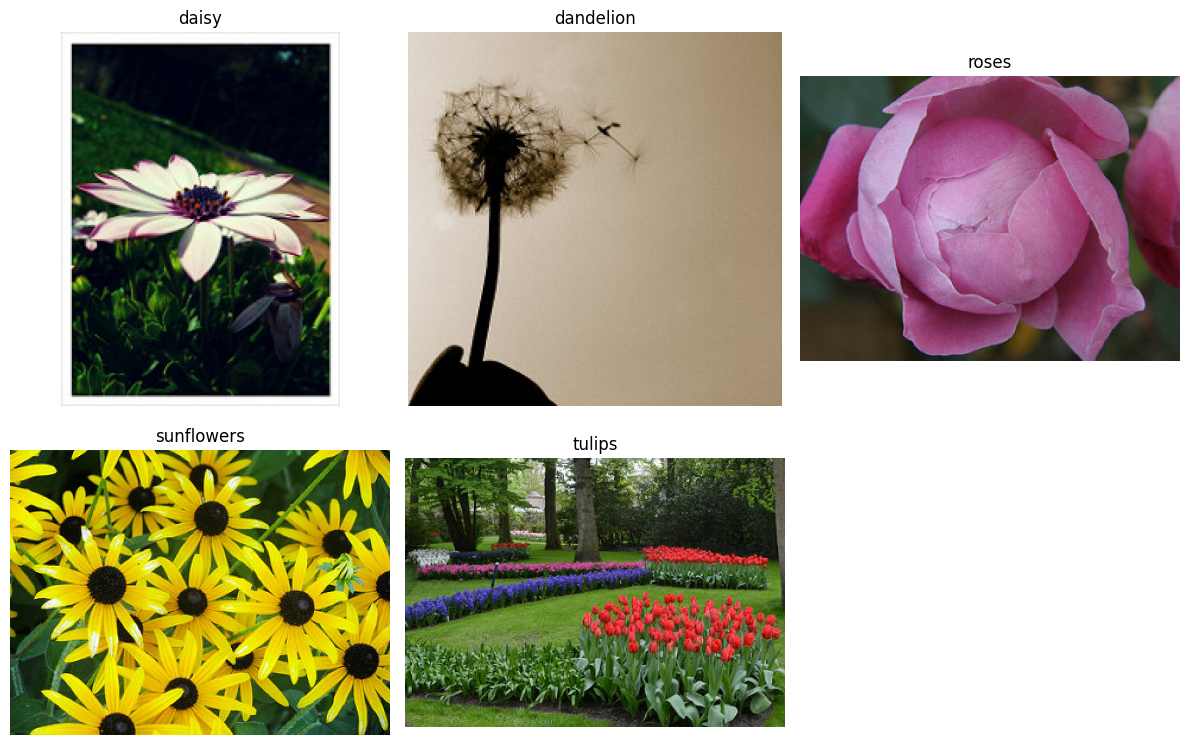

In [7]:
# Display sample images from each class

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, image_files[0])
    image = plt.imread(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Create the training dataset

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Training dataset created successfully.")

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Training dataset created successfully.


In [9]:
# Create the validation dataset

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Validation dataset created successfully.")

Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Validation dataset created successfully.


In [10]:
# Split the validation dataset into validation and test datasets

val_batches = tf.data.experimental.cardinality(val_ds)

test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Testing batches:", tf.data.experimental.cardinality(test_ds).numpy())

Training batches: 92
Validation batches: 12
Testing batches: 11


In [11]:
# Check image shape and number of classes

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image size:", images.shape[1:3])
    print("Number of classes:", len(class_names))

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image size: (224, 224)
Number of classes: 5


In [12]:
# Data augmentation for training images

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


In [13]:
# ResNet-50 preprocessing

from tensorflow.keras.applications.resnet50 import preprocess_input

def preprocess_train(images, labels):
    images = data_augmentation(images)
    images = preprocess_input(images)
    return images, labels


def preprocess_test(images, labels):
    images = preprocess_input(images)
    return images, labels


print("ResNet-50 preprocessing functions created successfully.")

ResNet-50 preprocessing functions created successfully.


In [14]:
# Apply preprocessing to the datasets

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    preprocess_train,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    preprocess_test,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    preprocess_test,
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Preprocessing and data augmentation applied successfully.")

Preprocessing and data augmentation applied successfully.


# Task 2: Model Implementation and Fine-tuning

## Pre-trained ResNet-50 Model

The selected research paper uses ResNet-50 as the pre-trained convolutional neural network. In this implementation, ResNet-50 with ImageNet pre-trained weights is used as the base model.

The original ImageNet classification layer is removed and replaced with new layers suitable for classifying the five flower categories in our dataset.

Initially, the convolutional base of the model will be frozen. Only the newly added classification layers will be trained. After the initial training stage, selected upper layers will be unfrozen and the model will be fine-tuned using a lower learning rate.


In [16]:
# Load pre-trained ResNet-50 model

from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet-50 loaded successfully!")
print("Number of layers:", len(base_model.layers))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet-50 loaded successfully!
Number of layers: 175


In [17]:
# Freeze the ResNet-50 base model

base_model.trainable = False

print("ResNet-50 base model is frozen.")

# Count trainable and non-trainable parameters

trainable_params = sum(
    np.prod(variable.shape)
    for variable in base_model.trainable_variables
)

non_trainable_params = sum(
    np.prod(variable.shape)
    for variable in base_model.non_trainable_variables
)

print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

ResNet-50 base model is frozen.
Trainable parameters: 0
Non-trainable parameters: 23587712


In [18]:
# Build the complete transfer learning model

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

print("Complete model created successfully!")

Complete model created successfully!


In [19]:
# Display model summary

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [20]:
# Compile the model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


# Feature Map Visualization

Feature maps are visual representations of the features extracted by convolutional layers of the pre-trained ResNet-50 model. They help us understand what visual patterns the model detects from input images.

In [21]:
# Visualize feature maps from an early convolutional layer

# Get one image from the test dataset
for images, labels in test_ds.take(1):
    sample_image = images[0:1]
    break

# Select an early convolutional layer
feature_layer = base_model.get_layer("conv1_conv")

# Create a model that outputs the selected layer's feature maps
feature_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=feature_layer.output
)

# Extract feature maps
feature_maps = feature_model(sample_image, training=False)

print("Feature map shape:", feature_maps.shape)

Feature map shape: (1, 112, 112, 64)


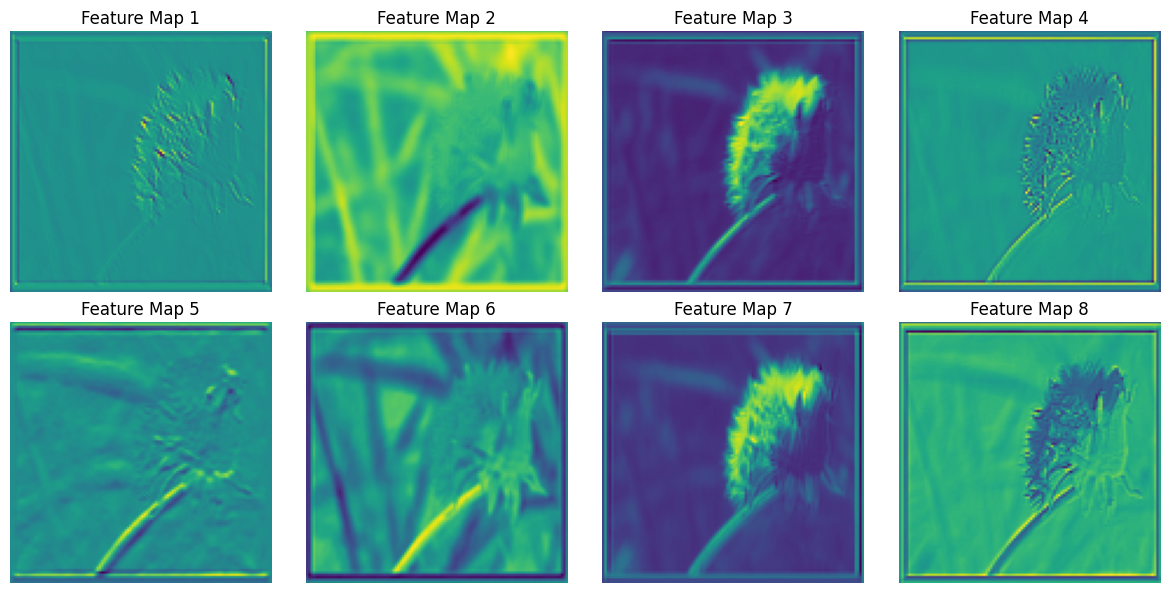

In [22]:
# Display feature maps

num_features = 8

plt.figure(figsize=(12, 6))

for i in range(num_features):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Fine-tuning the Pre-trained ResNet-50 Model

After the initial transfer learning stage, the top layers of the pre-trained ResNet-50 model are unfrozen. These layers are fine-tuned on the flower dataset using a smaller learning rate.

In [23]:
# Unfreeze the top layers of ResNet-50 for fine-tuning

base_model.trainable = True

# Freeze the initial layers and keep the last 20 layers trainable
for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Total ResNet-50 layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total ResNet-50 layers: 175
Trainable layers: 20


In [24]:
# Compile the model for fine-tuning

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


# Hyperparameter Optimization

The following hyperparameters were considered during fine-tuning:

- Optimizer: Adam
- Learning Rate: 0.0001
- Batch Size: 32
- Fine-tuning Epochs: 5

A smaller learning rate is used during fine-tuning to make small updates to the pre-trained weights and preserve the useful features learned from ImageNet.

In [28]:
# Fine-tune the model

FINE_TUNE_EPOCHS = 2

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS
)

Epoch 1/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 886s 10s/step - accuracy: 0.9564 - loss: 0.1258 - val_accuracy: 0.9398 - val_loss: 0.1868
Epoch 2/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 863s 9s/step - accuracy: 0.9745 - loss: 0.0804 - val_accuracy: 0.9450 - val_loss: 0.1949


In [29]:
# Selected hyperparameters

hyperparameters = {
    "Optimizer": "Adam",
    "Learning Rate": 0.0001,
    "Batch Size": 32,
    "Fine-tuning Epochs": 2
}

for parameter, value in hyperparameters.items():
    print(f"{parameter}: {value}")

Optimizer: Adam
Learning Rate: 0.0001
Batch Size: 32
Fine-tuning Epochs: 2


## Hyperparameter Selection

The Adam optimizer was selected because it provides adaptive learning rates and is commonly used for transfer learning. A learning rate of 0.0001 was selected for fine-tuning because a lower learning rate helps prevent large changes to the pre-trained weights. A batch size of 32 was used because it provides a practical balance between memory usage and training stability. Five epochs were selected for fine-tuning to allow the model to adapt to the flower dataset without excessive training.

In [30]:
# Evaluate the fine-tuned model on the test dataset

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

11/11 ━━━━━━━━━━━━━━━━━━━━ 71s 6s/step - accuracy: 0.9517 - loss: 0.1799
Test Loss: 0.17994515597820282
Test Accuracy: 0.9517045617103577


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [36]:
# Generate predictions for the test dataset

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model(images, training=False)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.9431818181818182
Precision: 0.9437405997568992
Recall   : 0.9431818181818182
F1-Score : 0.9432313240110315


In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [39]:
# Detailed classification report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

       daisy       0.97      0.94      0.95        64
   dandelion       0.93      0.97      0.95        80
       roses       0.90      0.92      0.91        59
  sunflowers       0.96      0.95      0.95        76
      tulips       0.96      0.93      0.94        73

    accuracy                           0.94       352
   macro avg       0.94      0.94      0.94       352
weighted avg       0.94      0.94      0.94       352



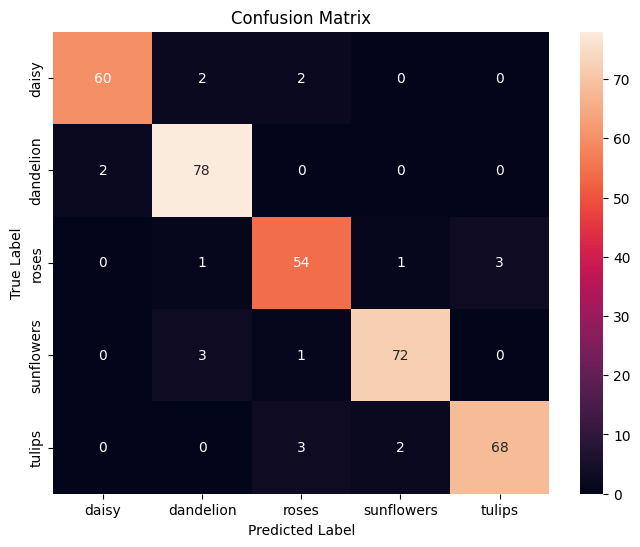

In [44]:
# Generate and display confusion matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

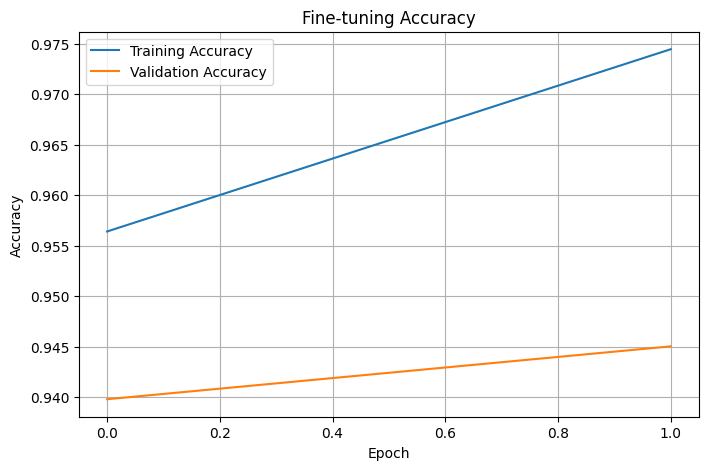

In [45]:
# Plot fine-tuning accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_fine.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_fine.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-tuning Accuracy")
plt.legend()
plt.grid(True)
plt.show()

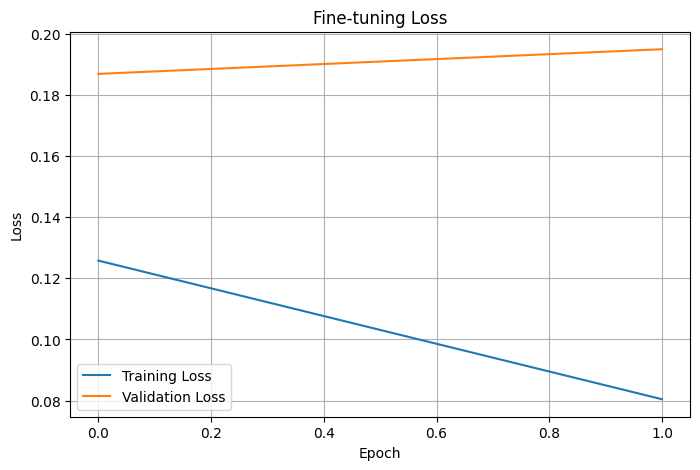

In [46]:
# Plot fine-tuning loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_fine.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fine.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-tuning Loss")
plt.legend()
plt.grid(True)
plt.show()

# Comparison with Research Paper

## Comparison of Results

The research paper uses a ResNet-50 model with ImageNet pre-trained weights for flower classification. The authors report their performance using classification metrics such as accuracy and F1-score.

In our implementation, the same general transfer learning approach was followed using ImageNet-pretrained ResNet-50. However, a publicly available Flower Photos dataset containing five flower classes was used instead of the extended dataset used in the research paper.

Therefore, the results obtained in our implementation cannot be directly compared numerically with the paper's results because the datasets and experimental conditions are different.

The comparison is mainly used to verify whether the transfer learning methodology can be successfully reproduced and applied to a similar flower classification problem.

# Modifications Made

The following modifications were made during implementation:

1. A publicly available flower dataset was used instead of the exact extended dataset used in the research paper.
2. The dataset contains five flower classes.
3. Images were resized to 224 × 224 pixels for ResNet-50.
4. Data augmentation was applied to the training images.
5. ImageNet-pretrained ResNet-50 was used as the base model.
6. The original classification layer was replaced with a new five-class classification layer.
7. Initially, the ResNet-50 base layers were frozen.
8. The final 20 layers were later unfrozen for fine-tuning.
9. Adam optimizer was used.
10. A learning rate of 0.0001 was used during fine-tuning.

# Conclusion

In this assignment, a research paper based on transfer learning with ResNet-50 was studied and implemented.

An ImageNet-pretrained ResNet-50 model was used for flower image classification. The model was initially used with frozen convolutional layers, followed by fine-tuning of the upper layers.

The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. Training and validation performance were also visualized.

The implementation demonstrates how a pre-trained deep learning model can be adapted to a new image classification problem using transfer learning and fine-tuning.

Although the dataset used in this implementation differs from the dataset used in the research paper, the main transfer learning methodology was reproduced successfully.

# Declaration

I hereby declare that this implementation was carried out for the Generative AI laboratory assignment. The selected research paper and its methodology were studied and reproduced using a similar publicly available dataset. The modifications made during implementation and the obtained experimental results have been documented.